In [1]:
# import sys
# !{sys.executable} -m pip install --upgrade pip
# !{sys.executable} -m pip install pandas

## Data pulled from
{{baseUrl}}/api/snaptrade/options/holdings?userid={{userId}}&userSecret={{userSecret}}&accountId={{accountID}}

and

{{baseUrl}}/api/accounts/activities?accountId=b199b32e-a5c2-44ab-b646-06901040df0c&startDate=2015-01-01&endDate=2026-11-10&limit=100000

In [2]:
import json
from pathlib import Path
import pandas as pd

p = Path("activities.json")
with p.open("r", encoding="utf-8") as f:
    data = json.load(f)

activities = data["activities"]

p = Path("optionHoldings.json")
with p.open("r", encoding="utf-8") as f:
    data = json.load(f)

option_holdings = data[ "holdings"]

In [3]:
option_holdings[0]

{'symbol': {'id': '2a77429b-99f5-4e34-916d-77cd4ac7f23a',
  'description': '',
  'option_symbol': {'id': '400463c7-5ef9-4d6e-b61f-9de99b86aa08',
   'ticker': 'PLTY  260320P00066000',
   'strike_price': 66,
   'expiration_date': '2026-03-20',
   'is_mini_option': False,
   'underlying_symbol': {'id': '2f088aea-2be6-410d-a36a-39c98ab61408',
    'symbol': 'PLTY',
    'description': 'YieldMax PLTR Option Income Strategy ETF',
    'currency': {'code': 'USD',
     'name': 'US Dollar',
     'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
    'exchange': {'id': '9f3ea556-15c5-4321-8983-ad4033ff802b',
     'code': 'ARCA',
     'mic_code': 'ARCX',
     'name': 'NYSE Arca',
     'suffix': None,
     'timezone': 'America/New_York',
     'start_time': '09:30:00',
     'close_time': '16:00:00'},
    'currencies': [],
    'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
     'code': 'et',
     'description': 'ETF',
     'is_supported': True},
    'raw_symbol': 'PLTY',
    'logo_url': '',
    'fi

## Look at one transaction

In [4]:
display(activities[0])


{'id': '85931fa7-d819-4489-a281-6ea54be8545a',
 'symbol': {'description': 'Vanguard Group, Inc. - Vanguard Total Stock Market ETF',
  'id': '8df8c08b-fbe5-4fe0-99ba-86e84d381fd0',
  'symbol': 'VTI',
  'raw_symbol': 'VTI',
  'currency': {'code': 'USD',
   'name': 'US Dollar',
   'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
  'exchange': {'id': '9f3ea556-15c5-4321-8983-ad4033ff802b',
   'code': 'ARCA',
   'mic_code': 'ARCX',
   'name': 'NYSE Arca',
   'suffix': None,
   'timezone': 'America/New_York',
   'start_time': '09:30:00',
   'close_time': '16:00:00'},
  'logo_url': '',
  'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
   'code': 'et',
   'description': 'ETF',
   'is_supported': True},
  'figi_code': 'BBG000HRBDF4',
  'figi_instrument': {'figi_code': 'BBG000HRBDF4',
   'figi_share_class': 'BBG001SHTB03'}},
 'option_symbol': None,
 'currency': {'code': 'USD',
  'name': 'US Dollar',
  'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
 'type': 'SELL',
 'description': 'SELL 0.79

## All types of activites

In [5]:
types = set(activity["type"] for activity in activities)
types

{'BUY',
 'CONTRIBUTION',
 'DIVIDEND',
 'FEE',
 'INTEREST',
 'OPTIONASSIGNMENT',
 'OPTIONEXERCISE',
 'OPTIONEXPIRATION',
 'REI',
 'SELL',
 'WITHDRAWAL'}

In [6]:
# count of types:
type_counts = {}
for activity in activities:
    t = activity["type"]
    type_counts[t] = type_counts.get(t, 0) + 1
    
type_counts

{'SELL': 472,
 'BUY': 853,
 'DIVIDEND': 305,
 'INTEREST': 23,
 'WITHDRAWAL': 6,
 'REI': 78,
 'OPTIONASSIGNMENT': 2,
 'CONTRIBUTION': 114,
 'OPTIONEXPIRATION': 10,
 'FEE': 49,
 'OPTIONEXERCISE': 1}

## separate the types into different arrays

In [7]:
activities_by_type = {}
for t in types:
    activities_by_type[t] = [activity for activity in activities if activity["type"] == t]
activities_by_type.keys()

dict_keys(['OPTIONEXPIRATION', 'DIVIDEND', 'REI', 'FEE', 'SELL', 'WITHDRAWAL', 'OPTIONASSIGNMENT', 'CONTRIBUTION', 'OPTIONEXERCISE', 'BUY', 'INTEREST'])

## Reformat

In [8]:
import json
print(json.dumps(activities_by_type.get('BUY', [])[0], indent=2))

{
  "id": "139b8214-1465-4f3e-9711-99c2f6eddfeb",
  "symbol": {
    "description": "J.P. Morgan Exchange-Traded Fund Trust - JPMorgan Nasdaq Equity Premium Income ETF",
    "id": "1c104ef0-6dcf-469a-be5b-35e158d56652",
    "symbol": "JEPQ",
    "raw_symbol": "JEPQ",
    "currency": {
      "code": "USD",
      "name": "US Dollar",
      "id": "57f81c53-bdda-45a7-a51f-032afd1ae41b"
    },
    "exchange": {
      "id": "ff4b2ffc-5a0e-4471-9cf5-95c0c30cdedd",
      "code": "NASDAQ",
      "mic_code": "XNAS",
      "name": "NASDAQ",
      "suffix": null,
      "timezone": "America/New_York",
      "start_time": "09:30:00",
      "close_time": "16:00:00"
    },
    "logo_url": "https://api.twelvedata.com/logo/gruppotim.it",
    "type": {
      "id": "8057ceb7-e073-4c77-8635-a1c9bc6442cb",
      "code": "et",
      "description": "ETF",
      "is_supported": true
    },
    "figi_code": "BBG016NKZDS8",
    "figi_instrument": {
      "figi_code": "BBG016NKZDS8",
      "figi_share_class": "BBG

In [9]:
# Count activities in the BUY bucket that include an option_symbol (not None)
buy_activities = activities_by_type.get('BUY', [])
option_count_buy = sum(1 for a in buy_activities if isinstance(a, dict) and a.get('option_symbol'))
print("BUY bucket - activities with option_symbol:", option_count_buy)

BUY bucket - activities with option_symbol: 264


In [10]:
count = 0
for activity in activities_by_type.get('BUY', []):
    temp = activity.get('option_symbol')
    if temp is not None:
        print(json.dumps(activity, indent=2))
        count += 1
    if count >= 3:
        break

{
  "id": "7add9e95-2105-47f7-9874-f4cd72e0d8b8",
  "symbol": {
    "description": "YieldMax PLTR Option Income Strategy ETF",
    "id": "2f088aea-2be6-410d-a36a-39c98ab61408",
    "symbol": "PLTY",
    "raw_symbol": "PLTY",
    "currency": {
      "code": "USD",
      "name": "US Dollar",
      "id": "57f81c53-bdda-45a7-a51f-032afd1ae41b"
    },
    "exchange": {
      "id": "9f3ea556-15c5-4321-8983-ad4033ff802b",
      "code": "ARCA",
      "mic_code": "ARCX",
      "name": "NYSE Arca",
      "suffix": null,
      "timezone": "America/New_York",
      "start_time": "09:30:00",
      "close_time": "16:00:00"
    },
    "logo_url": "",
    "type": {
      "id": "8057ceb7-e073-4c77-8635-a1c9bc6442cb",
      "code": "et",
      "description": "ETF",
      "is_supported": true
    },
    "figi_code": "BBG01Q6DWBN1",
    "figi_instrument": {
      "figi_code": "BBG01Q6DWBN1",
      "figi_share_class": null
    }
  },
  "option_symbol": {
    "id": "400463c7-5ef9-4d6e-b61f-9de99b86aa08",
  

In [26]:
count = 0
for activity in activities_by_type.get('SELL', []):
    temp = activity.get('option_symbol')
    if temp is not None:
        print(json.dumps(activity, indent=2))
        count += 1
    if count >= 3:
        break

{
  "id": "a9324b0e-6b41-43da-9f7b-8ad817e8cf71",
  "symbol": {
    "description": "YieldMax PLTR Option Income Strategy ETF",
    "id": "2f088aea-2be6-410d-a36a-39c98ab61408",
    "symbol": "PLTY",
    "raw_symbol": "PLTY",
    "currency": {
      "code": "USD",
      "name": "US Dollar",
      "id": "57f81c53-bdda-45a7-a51f-032afd1ae41b"
    },
    "exchange": {
      "id": "9f3ea556-15c5-4321-8983-ad4033ff802b",
      "code": "ARCA",
      "mic_code": "ARCX",
      "name": "NYSE Arca",
      "suffix": null,
      "timezone": "America/New_York",
      "start_time": "09:30:00",
      "close_time": "16:00:00"
    },
    "logo_url": "",
    "type": {
      "id": "8057ceb7-e073-4c77-8635-a1c9bc6442cb",
      "code": "et",
      "description": "ETF",
      "is_supported": true
    },
    "figi_code": "BBG01Q6DWBN1",
    "figi_instrument": {
      "figi_code": "BBG01Q6DWBN1",
      "figi_share_class": null
    }
  },
  "option_symbol": {
    "id": "663f7a4f-696a-411f-8153-f7b8588ab086",
  

In [11]:
from collections import Counter
import json

def get_symbol_type_description(activity):
    # Navigate safely: activity -> symbol -> type -> description
    symbol = activity.get('symbol') if isinstance(activity, dict) else None
    if not isinstance(symbol, dict):
        return "UNKNOWN"
    t = symbol.get('type')
    if isinstance(t, dict):
        return t.get('description') or "UNKNOWN"
    return str(t) if t is not None else "UNKNOWN"

# Count descriptions for BUY activities
buy_activities = activities_by_type.get('BUY', [])
type_count = Counter(get_symbol_type_description(a) for a in buy_activities)

# Pretty-print results
print(json.dumps(type_count, indent=2))
# or as Counter
print(type_count.most_common())

{
  "ETF": 370,
  "Common Stock": 467,
  "American Depositary Receipt": 13,
  "Bond": 3
}
[('Common Stock', 467), ('ETF', 370), ('American Depositary Receipt', 13), ('Bond', 3)]


In [12]:
activities_by_type['OPTIONEXPIRATION'][1]

{'id': '00603c26-fd26-4183-894d-608d9845796c',
 'symbol': {'description': 'Invesco Capital Management LLC - Invesco QQQ Trust Series 1',
  'id': 'a0ba2665-6e84-4b0f-8e30-e21ef18494d1',
  'symbol': 'QQQ',
  'raw_symbol': 'QQQ',
  'currency': {'code': 'USD',
   'name': 'US Dollar',
   'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
  'exchange': {'id': 'ff4b2ffc-5a0e-4471-9cf5-95c0c30cdedd',
   'code': 'NASDAQ',
   'mic_code': 'XNAS',
   'name': 'NASDAQ',
   'suffix': None,
   'timezone': 'America/New_York',
   'start_time': '09:30:00',
   'close_time': '16:00:00'},
  'logo_url': '',
  'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
   'code': 'et',
   'description': 'ETF',
   'is_supported': True},
  'figi_code': 'BBG000BSWN45',
  'figi_instrument': {'figi_code': 'BBG000BSWN45',
   'figi_share_class': 'BBG001S9GN63'}},
 'option_symbol': {'id': '6ac313fc-9d33-479b-ad1b-01dfa1981c59',
  'ticker': 'QQQ   250411P00442000',
  'strike_price': 442,
  'expiration_date': '2025-04-11',
  'i

In [ ]:
activities_by_type['OPTIONEXERCISE'][1]

IndexError: list index out of range

In [13]:
activities_by_type['OPTIONASSIGNMENT'][1]

{'id': '133fb470-b388-49dd-8eac-77eed80a3b3a',
 'symbol': {'description': 'SSgA Active Trust - SPDR S&P 500 ETF Trust',
  'id': 'ee576918-ffd1-4908-9cc5-ca2469759e83',
  'symbol': 'SPY',
  'raw_symbol': 'SPY',
  'currency': {'code': 'USD',
   'name': 'US Dollar',
   'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
  'exchange': {'id': '9f3ea556-15c5-4321-8983-ad4033ff802b',
   'code': 'ARCA',
   'mic_code': 'ARCX',
   'name': 'NYSE Arca',
   'suffix': None,
   'timezone': 'America/New_York',
   'start_time': '09:30:00',
   'close_time': '16:00:00'},
  'logo_url': '',
  'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
   'code': 'et',
   'description': 'ETF',
   'is_supported': True},
  'figi_code': 'BBG000BDTF76',
  'figi_instrument': {'figi_code': 'BBG000BDTF76',
   'figi_share_class': 'BBG001S72SM3'}},
 'option_symbol': {'id': '7326f07c-5b61-43e0-8dc7-0164922c523e',
  'ticker': 'SPY   250422C00515000',
  'strike_price': 515,
  'expiration_date': '2025-04-22',
  'is_mini_option': 

### WithDrawal

In [14]:
withdrawal_records = []
for activity in activities_by_type["WITHDRAWAL"]:
    withdrawal_records.append({
        "amount": activity["amount"],
        "tradeDate": activity["trade_date"]
    })

### INTEREST

In [15]:
interest_records = []
for activity in activities_by_type["INTEREST"]:
    interest_records.append({
        "amount": activity["amount"],
        "tradeDate": activity["trade_date"]
    })

### Buys

In [16]:
# date --> symbol, units, price, amount
reformatted_buys = []
for activity in activities_by_type["BUY"]:
    reformatted_buys.append({
        "tradeDate": activity["trade_date"],
        "symbol": activity["symbol"]['symbol'],
        "units": activity["units"],
        "price": activity["price"],
        "amount": activity["amount"]
    })

In [17]:
activities_by_type["BUY"][0]

{'id': '139b8214-1465-4f3e-9711-99c2f6eddfeb',
 'symbol': {'description': 'J.P. Morgan Exchange-Traded Fund Trust - JPMorgan Nasdaq Equity Premium Income ETF',
  'id': '1c104ef0-6dcf-469a-be5b-35e158d56652',
  'symbol': 'JEPQ',
  'raw_symbol': 'JEPQ',
  'currency': {'code': 'USD',
   'name': 'US Dollar',
   'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
  'exchange': {'id': 'ff4b2ffc-5a0e-4471-9cf5-95c0c30cdedd',
   'code': 'NASDAQ',
   'mic_code': 'XNAS',
   'name': 'NASDAQ',
   'suffix': None,
   'timezone': 'America/New_York',
   'start_time': '09:30:00',
   'close_time': '16:00:00'},
  'logo_url': 'https://api.twelvedata.com/logo/gruppotim.it',
  'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
   'code': 'et',
   'description': 'ETF',
   'is_supported': True},
  'figi_code': 'BBG016NKZDS8',
  'figi_instrument': {'figi_code': 'BBG016NKZDS8',
   'figi_share_class': 'BBG016NKZFF7'}},
 'option_symbol': None,
 'currency': {'code': 'USD',
  'name': 'US Dollar',
  'id': '57f81c53-b

### Sells

In [18]:
reformatted_sells = []
for activity in activities_by_type["SELL"]:
    reformatted_sells.append({
        "tradeDate": activity["trade_date"],
        "symbol": activity["symbol"]['symbol'],
        "units": activity["units"],
        "price": activity["price"],
        "amount": activity["amount"]
    })

In [19]:
activities_by_type["SELL"][0]

{'id': '85931fa7-d819-4489-a281-6ea54be8545a',
 'symbol': {'description': 'Vanguard Group, Inc. - Vanguard Total Stock Market ETF',
  'id': '8df8c08b-fbe5-4fe0-99ba-86e84d381fd0',
  'symbol': 'VTI',
  'raw_symbol': 'VTI',
  'currency': {'code': 'USD',
   'name': 'US Dollar',
   'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
  'exchange': {'id': '9f3ea556-15c5-4321-8983-ad4033ff802b',
   'code': 'ARCA',
   'mic_code': 'ARCX',
   'name': 'NYSE Arca',
   'suffix': None,
   'timezone': 'America/New_York',
   'start_time': '09:30:00',
   'close_time': '16:00:00'},
  'logo_url': '',
  'type': {'id': '8057ceb7-e073-4c77-8635-a1c9bc6442cb',
   'code': 'et',
   'description': 'ETF',
   'is_supported': True},
  'figi_code': 'BBG000HRBDF4',
  'figi_instrument': {'figi_code': 'BBG000HRBDF4',
   'figi_share_class': 'BBG001SHTB03'}},
 'option_symbol': None,
 'currency': {'code': 'USD',
  'name': 'US Dollar',
  'id': '57f81c53-bdda-45a7-a51f-032afd1ae41b'},
 'type': 'SELL',
 'description': 'SELL 0.79

i need to keep track of 
deposits and withdrawls
devidends
daily returns/changes in value of stocks/etf/bonds/crypto


## Contribution

In [20]:
contribution_records = []
for activity in activities_by_type["CONTRIBUTION"]:
    contribution_records.append({
        "amount": activity["amount"],
        "tradeDate": activity["trade_date"]
    })

## Dividends

In [21]:
dividend_records = []
for activity in activities_by_type["DIVIDEND"]:
    dividend_records.append({
        "symbol": activity["symbol"]['symbol'],
        "amount": activity["amount"],
        "tradeDate": activity["trade_date"]
    })

## FEE

In [22]:
fee_records = []
for activity in activities_by_type["FEE"]:
    fee_records.append({
        "amount": activity["amount"],
        "tradeDate": activity["trade_date"]
    })

metrics: {
      sharpe: {
        oneMonth: { type: Number, default: null },
        threeMonth: { type: Number, default: null },
        sixMonth: { type: Number, default: null },
        oneYear: { type: Number, default: null },
        inceptionToDate: { type: Number, default: null },
      },
      sortino: {
        oneMonth: { type: Number, default: null },
        threeMonth: { type: Number, default: null },
        sixMonth: { type: Number, default: null },
        oneYear: { type: Number, default: null },
        inceptionToDate: { type: Number, default: null },
      },
      calmar: {
        oneYear: { type: Number, default: null },
        inceptionToDate: { type: Number, default: null },
      },
      volatility: {
        oneMonth: { type: Number, default: null },
        threeMonth: { type: Number, default: null },
        oneYear: { type: Number, default: null },
        inceptionToDate: { type: Number, default: null },
      },
      downsideVolatility: {
        oneMonth: { type: Number, default: null },
        threeMonth: { type: Number, default: null },
        oneYear: { type: Number, default: null },
        inceptionToDate: { type: Number, default: null },
      },
      drawdown: {
        current: { type: Number, default: null },
        maxToDate: { type: Number, default: null },
        oneMonth: { type: Number, default: null },
        oneYear: { type: Number, default: null },
        rollingPeak: { type: Number, default: null },
      },
      beta: {
        vsSPY: {
          oneYear: { type: Number, default: null },
          inceptionToDate: { type: Number, default: null },
        },
      },
      alpha: {
        vsSPY: {
          oneYear: { type: Number, default: null },
          inceptionToDate: { type: Number, default: null },
        },
      }

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AVAX"}}}
$AVAX: possibly delisted; no timezone found
$ATVI: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found
$DOGE: possibly delisted; no timezone found
$RDBX: possibly delisted; no timezone found
$ZNGA: possibly delisted; no timezone found
$MCFE: possibly delisted; no timezone found
$DWAC: possibly delisted; no timezone found
$BRK.B: possibly delisted; no timezone found
$CS: possibly delisted; no timezone found
$MOTV: possibly delisted; no timezone found
$IPA: possibly delisted; no timezone found
$DFNS: possibly delisted; no timezone found
$FSR: possibly delisted; no timezone found

14 Failed downloads:
['AVAX', 'ATVI', 'TWTR', 'DOGE', 'RDBX', 'ZNGA', 'MCFE', 'DWAC', 'BRK.B', 'CS', 'MOTV', 'DFNS', 'IPA', 'FSR']: YFTzMissingError('possibly delisted; no timezone found')


=== Portfolio (tail) ===
            cash_value   stock_value   total_value  deposit_withdrawal  \
date                                                                     
2025-11-13   16188.755  32303.627987  48492.382987                 0.0   
2025-11-14   16188.755  32323.332463  48512.087463                 0.0   
2025-11-15   16188.755  32323.332463  48512.087463                 0.0   
2025-11-16   16188.755  32323.332463  48512.087463                 0.0   
2025-11-17   16188.755  32103.007012  48291.762012                 0.0   

            simple_returns  cum_return  equity_index  
date                                                  
2025-11-13       -0.018588   -0.447505      0.552495  
2025-11-14        0.000406   -0.447280      0.552720  
2025-11-15        0.000000   -0.447280      0.552720  
2025-11-16        0.000000   -0.447280      0.552720  
2025-11-17       -0.004542   -0.449790      0.550210  

Total cumulative external flows (net deposits/withdrawals):
61060.8


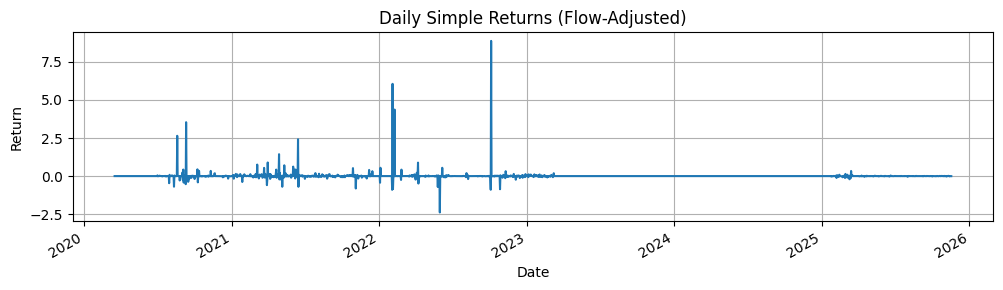

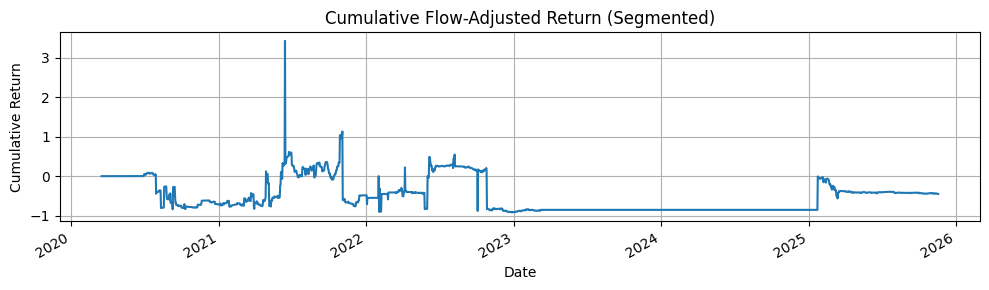

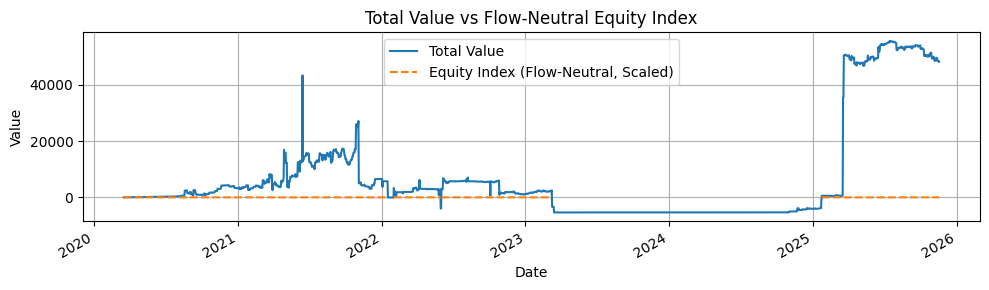

In [23]:
# KEEP 

from collections import defaultdict
from datetime import timedelta
from pathlib import Path
import json

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# -------------------------------------------------------------
# 1. STOCK POSITIONS + STOCK VALUE (from BUY/SELL/REI/OPTIONS)
# -------------------------------------------------------------

def signed_units(act: dict) -> float:
    """
    Convert an activity record to a signed share quantity.

    SnapTrade conventions (typical):
    - BUY  : units > 0  (cash out)
    - SELL : units < 0  (cash in)
    - REI  : dividend reinvestment (treated as BUY of shares)

    We normalise:
      - SELL -> negative units
      - BUY/REI -> positive units
      - other types -> 0 (no position change)
    """
    t = str(act.get("type", "")).upper()
    u = float(act.get("units", 0.0))

    if t == "SELL":
        return -abs(u)
    elif t in ("BUY", "REI"):
        return abs(u)
    else:
        return 0.0


def build_daily_positions_and_stock_value(activities):
    """
    From a list of SnapTrade activities, build:

    - positions_df: shares per symbol per calendar day (index = Timestamp, tz-naive)
    - stock_value:  total stock/ETF/etc. market value per day (Series)
    """
    activities = list(activities)
    if not activities:
        raise ValueError("No activities provided")

    transactions_by_date = defaultdict(lambda: defaultdict(float))

    POSITION_TYPES = {
        "BUY",
        "SELL",
        "REI",
        "OPTIONASSIGNMENT",
        "OPTIONEXERCISE",
    }

    for activity in activities:
        t = str(activity.get("type", "")).upper()
        if t not in POSITION_TYPES:
            continue

        sym_info = activity.get("symbol")
        if not sym_info or "symbol" not in sym_info:
            continue

        sym = sym_info["symbol"]

        trade_date_raw = activity.get("trade_date")
        if not trade_date_raw:
            continue

        trade_date = pd.to_datetime(trade_date_raw).date()
        units = signed_units(activity)
        if units == 0.0:
            continue

        transactions_by_date[trade_date][sym] += units

    if not transactions_by_date:
        raise ValueError("No BUY/SELL/REI/option transactions with symbols found in activities")

    all_symbols = {
        a["symbol"]["symbol"]
        for a in activities
        if a.get("symbol") and isinstance(a["symbol"], dict) and a["symbol"].get("symbol")
    }

    splits_data = {}
    for sym in all_symbols:
        try:
            s = yf.Ticker(sym).splits
        except Exception:
            continue

        if not s.empty:
            s.index = s.index.date
            splits_data[sym] = s

    all_dates = set(transactions_by_date.keys())
    for s in splits_data.values():
        all_dates.update(s.index)

    if not all_dates:
        raise ValueError("No dates found in transactions or splits.")

    min_date = min(all_dates)
    max_date = max(all_dates)
    date_range = pd.date_range(start=min_date, end=max_date, freq="D")

    cumulative_by_date = {}
    current_positions = {}

    for ts in date_range:
        current_date = ts.date()

        # splits
        for sym, split_series in splits_data.items():
            if current_date in split_series.index:
                factor = float(split_series.loc[current_date])
                if sym in current_positions:
                    current_positions[sym] *= factor

        # transactions
        if current_date in transactions_by_date:
            for sym, delta_units in transactions_by_date[current_date].items():
                new_units = current_positions.get(sym, 0.0) + delta_units
                if abs(new_units) < 1e-3:
                    current_positions.pop(sym, None)
                else:
                    current_positions[sym] = new_units

        cumulative_by_date[current_date] = current_positions.copy()

    positions_df = (
        pd.DataFrame.from_dict(cumulative_by_date, orient="index")
        .fillna(0.0)
        .sort_index()
    )
    positions_df.index = pd.to_datetime(positions_df.index)
    positions_df.index.name = "date"

    tickers = positions_df.columns.tolist()
    if not tickers:
        raise ValueError("No tickers found in positions_df")

    min_date, max_date = positions_df.index.min(), positions_df.index.max()

    price_df = yf.download(
        tickers=tickers,
        start=min_date,
        end=max_date + timedelta(days=1),
        progress=False,
        auto_adjust=False,
    )["Close"]

    if isinstance(price_df, pd.Series):
        price_df = price_df.to_frame(name=tickers[0])

    price_df = price_df.reindex(positions_df.index).ffill()

    valued_positions = positions_df * price_df
    stock_value = valued_positions.sum(axis=1)
    stock_value.name = "stock_value"

    return positions_df, stock_value


# -------------------------------------------------------------
# 2. CASH SERIES + DEPOSITS/WITHDRAWALS (external flows)
# -------------------------------------------------------------

def build_cash_and_flows(activities):
    """
    Build:
      - cash_value:     running cash balance (starting from 0)
      - cash_flow_day:  net cash flow per day from ALL actions
      - ext_flow_day:   net external flow per day (CONTRIBUTION/DEPOSIT/WITHDRAWAL)
      - ext_flow_cum:   cumulative external flows (time series)
    """
    activities = list(activities)
    df = pd.DataFrame(activities)

    if df.empty:
        empty = pd.Series(dtype="float64")
        return (
            empty.rename("cash_value"),
            empty.rename("net_cash_flow"),
            empty.rename("external_flow"),
            empty.rename("external_flow_cumulative"),
        )

    if "trade_date" not in df.columns:
        raise ValueError("Expected 'trade_date' in activities")
    if "amount" not in df.columns:
        raise ValueError("Expected 'amount' in activities")
    if "type" not in df.columns:
        raise ValueError("Expected 'type' in activities")

    dt = pd.to_datetime(df["trade_date"])
    df["date"] = dt.dt.date
    df["date"] = pd.to_datetime(df["date"])

    df["amount"] = pd.to_numeric(df["amount"], errors="coerce").fillna(0.0)
    df["type"] = df["type"].astype(str).str.upper()

    cash_flow_day = df.groupby("date")["amount"].sum().sort_index()
    cash_flow_day.name = "net_cash_flow"
    cash_value = cash_flow_day.cumsum()
    cash_value.name = "cash_value"

    EXT_TYPES = {"CONTRIBUTION", "DEPOSIT", "WITHDRAWAL"}
    ext = df[df["type"].isin(EXT_TYPES)].copy()

    if not ext.empty:
        ext.loc[ext["type"] == "WITHDRAWAL", "amount"] = -ext.loc[
            ext["type"] == "WITHDRAWAL", "amount"
        ].abs()
        ext.loc[ext["type"].isin({"CONTRIBUTION", "DEPOSIT"}), "amount"] = ext.loc[
            ext["type"].isin({"CONTRIBUTION", "DEPOSIT"})
        ]["amount"].abs()

        ext_flow_day = ext.groupby("date")["amount"].sum().sort_index()
        ext_flow_day.name = "external_flow"
        ext_flow_cum = ext_flow_day.cumsum()
        ext_flow_cum.name = "external_flow_cumulative"
    else:
        ext_flow_day = pd.Series(dtype="float64", name="external_flow")
        ext_flow_cum = pd.Series(dtype="float64", name="external_flow_cumulative")

    return cash_value, cash_flow_day, ext_flow_day, ext_flow_cum


# -------------------------------------------------------------
# 3. FULL PORTFOLIO TIMESERIES (RETURNS + EQUITY INDEX)
# -------------------------------------------------------------

def build_portfolio_timeseries(activities):
    """
    Build a portfolio timeseries with:

      - cash_value
      - stock_value
      - total_value = cash + stocks
      - deposit_withdrawal: net external flow per day
      - simple_returns: (V_curr - (V_prev + CF)) / (V_prev + CF)
      - cum_return: cumulative return per active segment (starts at 0 for each)
      - equity_index: normalized equity curve per segment (starts at 1 for each)

    Also returns:
      - positions_df (shares per symbol per day)
      - external_flows_total (scalar: net deposits/withdrawals)
    """
    # 1) Stocks
    positions_df, stock_value = build_daily_positions_and_stock_value(activities)

    # 2) Cash + external flows
    cash_value, cash_flow_day, ext_flow_day, ext_flow_cum = build_cash_and_flows(activities)

    # 3) Align on common date index
    idx = stock_value.index.union(cash_value.index)
    idx = idx.union(ext_flow_day.index)
    idx = idx.union(ext_flow_cum.index)
    idx = idx.sort_values()

    stock_value = stock_value.reindex(idx).ffill().fillna(0.0)
    cash_value = cash_value.reindex(idx).ffill().fillna(0.0)
    total_value = stock_value + cash_value

    # Per-day external flows (deposits/withdrawals), 0 where none
    ext_daily = ext_flow_day.reindex(idx).fillna(0.0)

    external_flows_ts = ext_flow_cum.reindex(idx).ffill().fillna(0.0)
    external_flows_total = external_flows_ts.iloc[-1] if len(external_flows_ts) else 0.0

    # 4) Daily simple returns:
    #    (new value - (prev day + cash flow)) / (prev day + cash flow)
    simple_returns = pd.Series(index=idx, dtype="float64")
    if len(idx) > 0:
        simple_returns.iloc[0] = 0.0
        for i in range(1, len(idx)):
            V_prev = total_value.iloc[i - 1]
            CF = ext_daily.iloc[i]          # net deposit/withdrawal for day i
            base = V_prev + CF              # (prev day value + cash flow)
            V_curr = total_value.iloc[i]    # new value

            if base <= 0:
                simple_returns.iloc[i] = 0.0
            else:
                simple_returns.iloc[i] = (V_curr - base) / base

    simple_returns.name = "simple_returns"

    # 5) Identify "alive" segments (account has non-trivial value)
    THRESH = 1e-3
    alive = total_value > THRESH

    # Start of a new alive segment = today alive, yesterday not alive
    start_seg = alive & ~alive.shift(fill_value=False)
    segment_id = start_seg.cumsum()
    segment_id[~alive] = 0  # 0 = dead periods

    cum_return = pd.Series(index=idx, dtype="float64")
    equity_index = pd.Series(index=idx, dtype="float64")

    # For each alive segment, compound returns separately
    for seg in range(1, int(segment_id.max()) + 1):
        mask = segment_id == seg
        if not mask.any():
            continue

        sr_seg = simple_returns[mask]

        # cumulative return (starts at 0)
        seg_cum = (1 + sr_seg).cumprod() - 1
        cum_return[mask] = seg_cum

        # equity index (starts at 1)
        seg_eq = (1 + sr_seg).cumprod()
        equity_index[mask] = seg_eq

    # Dead periods:
    # - cum_return: flat-lined (carry last value forward, start at 0 before first segment)
    cum_return = cum_return.ffill().fillna(0.0)
    # - equity_index: NaN for dead periods (so plots show gaps)
    equity_index[~alive] = np.nan

    cum_return.name = "cum_return"
    equity_index.name = "equity_index"

    # 6) Final portfolio DataFrame
    portfolio_df = pd.DataFrame(
        {
            "cash_value": cash_value,
            "stock_value": stock_value,
            "total_value": total_value,
            "deposit_withdrawal": ext_daily,
            "simple_returns": simple_returns,
            "cum_return": cum_return,
            "equity_index": equity_index,
        }
    )

    return (
        portfolio_df,
        positions_df,
        external_flows_total,
    )


# -------------------------------------------------------------
# 4. EXAMPLE USAGE + PLOTS
# -------------------------------------------------------------

if __name__ == "__main__":
    p = Path("activities.json")
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    activities = data["activities"]

    (
        portfolio_df,
        positions_df,
        external_flows_total,
    ) = build_portfolio_timeseries(activities)

    print("=== Portfolio (tail) ===")
    print(portfolio_df.tail())

    print("\nTotal cumulative external flows (net deposits/withdrawals):")
    print(external_flows_total)

    # ---------- Plots ----------

    # 1) Daily simple returns
    plt.figure(figsize=(10, 3))
    portfolio_df["simple_returns"].plot()
    plt.title("Daily Simple Returns (Flow-Adjusted)")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.grid(True)
    plt.tight_layout()

    # 2) Cumulative return (segmented)
    plt.figure(figsize=(10, 3))
    portfolio_df["cum_return"].plot()
    plt.title("Cumulative Flow-Adjusted Return (Segmented)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.tight_layout()

    # 3) Total value vs normalized equity index (scaled to start value)
    plt.figure(figsize=(10, 3))
    portfolio_df["total_value"].plot(label="Total Value")

    # Scale equity_index so first non-NaN aligns with first non-zero total_value
    alive = portfolio_df["equity_index"].notna()
    if alive.any():
        first_idx = portfolio_df.index[alive.argmax()]
        scale_start_val = portfolio_df.loc[first_idx, "total_value"]
        (portfolio_df["equity_index"] * scale_start_val).plot(
            label="Equity Index (Flow-Neutral, Scaled)", linestyle="--"
        )

    plt.title("Total Value vs Flow-Neutral Equity Index")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()



In [ ]:
from helper_portfolio_metrics import (
    compute_total_and_1y_metrics,
    compute_period_metrics,
)


if __name__ == "__main__":
    p = Path("activities.json")
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    activities = data["activities"]

    # 1) Build portfolio timeseries first
    (
        portfolio_df,
        positions_df,
        external_flows_total,
    ) = build_portfolio_timeseries(activities)

    # ----- Metrics -----

    # Optional: benchmark daily returns (e.g. SPY)
    # For now you can leave this as None
    benchmark_returns = None

    # # A) 1Y + ITD metrics
    # metrics_1y_itd = compute_total_and_1y_metrics(
    #     portfolio_df,
    #     benchmark_returns=benchmark_returns,
    #     risk_free_annual=0.02,
    #     var_level=0.95,
    # )
    # print("\n=== Metrics (1Y & ITD) ===")
    # print(metrics_1y_itd)

    # B) 1M, 3M, YTD, 1Y, ITD metrics
    period_metrics = compute_period_metrics(
        portfolio_df,
        benchmark_returns=benchmark_returns,
        risk_free_annual=0.02,
        var_level=0.95,
        periods=("1M", "3M", "YTD", "1Y", "ITD"),
    )
    print("\n=== Period Metrics (1M, 3M, YTD, 1Y, ITD) ===")
    print(period_metrics)

    # ----- (rest of your plots, etc.) -----
    print("=== Portfolio (tail) ===")
    print(portfolio_df.tail())

    # ----------- Plots ----------


$AVAX: possibly delisted; no timezone found
$ATVI: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found
$DOGE: possibly delisted; no timezone found
$RDBX: possibly delisted; no timezone found
$ZNGA: possibly delisted; no timezone found
$MCFE: possibly delisted; no timezone found
$DWAC: possibly delisted; no timezone found
$BRK.B: possibly delisted; no timezone found
$CS: possibly delisted; no timezone found
$MOTV: possibly delisted; no timezone found
$IPA: possibly delisted; no timezone found
$DFNS: possibly delisted; no timezone found
$FSR: possibly delisted; no timezone found

14 Failed downloads:
['AVAX', 'ATVI', 'TWTR', 'DOGE', 'RDBX', 'ZNGA', 'MCFE', 'DWAC', 'BRK.B', 'CS', 'MOTV', 'IPA', 'DFNS', 'FSR']: YFTzMissingError('possibly delisted; no timezone found')



=== Metrics (1Y & ITD) ===
        total_return  volatility    sharpe   sortino  beta       var  \
period                                                                 
1Y         -0.449790    0.469026 -0.691917 -0.625178   NaN  0.024219   
ITD        -1.008537    4.831115  0.624936  1.105652   NaN  0.055924   

            cvar  max_drawdown  
period                          
1Y      0.072595     -0.564892  
ITD     0.231616     -1.037303  

=== Period Metrics (1M, 3M, YTD, 1Y, ITD) ===
        total_return  volatility    sharpe   sortino  beta       var  \
period                                                                 
1M         -0.011628    0.126739 -0.822860 -0.949215   NaN  0.016832   
3M         -0.053253    0.101494 -1.607192 -1.651003   NaN  0.013697   
YTD        -0.449790    0.500861 -0.733173 -0.707418   NaN  0.032686   
1Y         -0.449790    0.469026 -0.691917 -0.625178   NaN  0.024219   
ITD        -1.008537    4.831115  0.624936  1.105652   NaN  0.055924   


$AVAX: possibly delisted; no timezone found
$ATVI: possibly delisted; no timezone found
$BRK.B: possibly delisted; no timezone found
$CS: possibly delisted; no timezone found
$MOTV: possibly delisted; no timezone found
$DFNS: possibly delisted; no timezone found
$ZNGA: possibly delisted; no timezone found
$MCFE: possibly delisted; no timezone found
$DOGE: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found

1 Failed download:
['BAC200814C00027000']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['KO200918C00050000']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['KO200828C00049000']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['BAC220121C00025000']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['SBUX210416C00082500']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['SPY201009C00354000']: YFTzMissingEr

=== Portfolio (tail) ===
            cash_value   stock_value   total_value  deposit_withdrawal  \
date                                                                     
2025-11-13   16188.755  33835.554988  50024.309988                 0.0   
2025-11-14   16188.755  33868.617390  50057.372390                 0.0   
2025-11-15   16188.755  33868.617390  50057.372390                 0.0   
2025-11-16   16188.755  33868.617390  50057.372390                 0.0   
2025-11-17   16188.755  33642.215412  49830.970412                 0.0   

            simple_returns  cum_return  equity_index  
date                                                  
2025-11-13       -0.018222   -0.633291      0.366709  
2025-11-14        0.000661   -0.633049      0.366951  
2025-11-15        0.000000   -0.633049      0.366951  
2025-11-16        0.000000   -0.633049      0.366951  
2025-11-17       -0.004523   -0.634708      0.365292  

Total cumulative external flows (net deposits/withdrawals):
61060.8


/var/folders/fp/nkfjsy052j30gp28hh22jbh00000gn/T/ipykernel_20430/2797619622.py:227: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  price_df[sym] = close


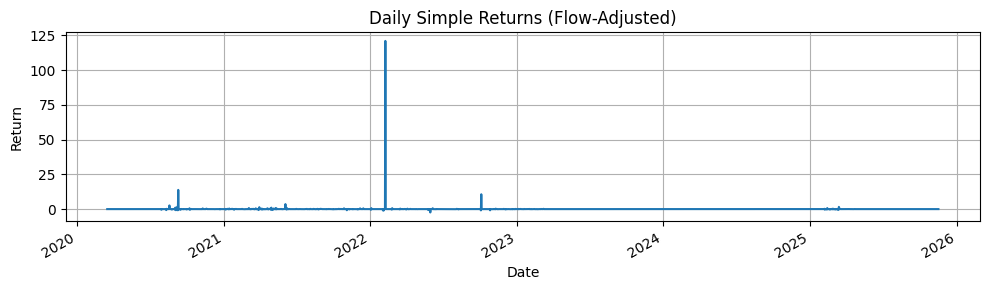

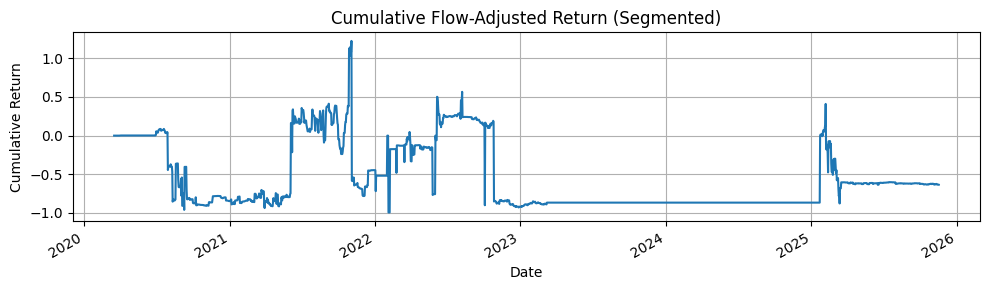

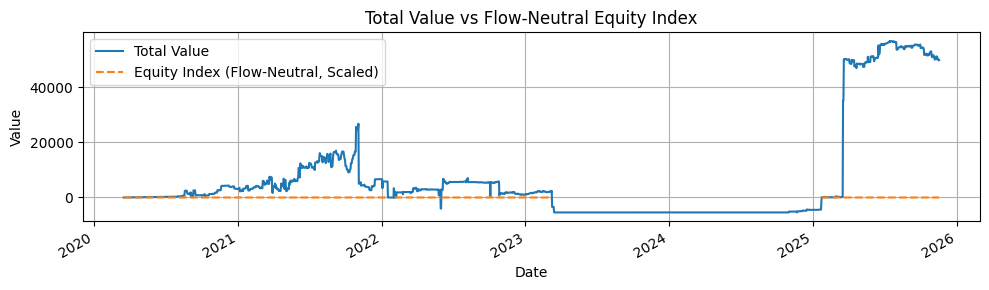

In [33]:
from collections import defaultdict
from datetime import timedelta
from pathlib import Path
import json

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


# -------------------------------------------------------------
# 1. STOCK/OPTION POSITIONS + MARKET VALUE (from BUY/SELL/REI/OPTIONS)
# -------------------------------------------------------------

def signed_units(act: dict) -> float:
    """
    Convert an activity record to a signed share/contract quantity.

    SnapTrade conventions (typical):
    - BUY  : units > 0  (cash out)
    - SELL : units < 0  (cash in)
    - REI  : dividend reinvestment (treated as BUY of shares)

    We normalise:
      - SELL -> negative units
      - BUY/REI -> positive units
      - OPTIONASSIGNMENT / OPTIONEXERCISE / OPTIONEXPIRATION:
          treated as closing long contracts (negative units)
      - other types -> 0 (no position change)
    """
    t = str(act.get("type", "")).upper()
    u = float(act.get("units", 0.0))

    if t == "SELL":
        return -abs(u)
    elif t in ("BUY", "REI"):
        return abs(u)
    elif t in ("OPTIONASSIGNMENT", "OPTIONEXERCISE", "OPTIONEXPIRATION"):
        # Close out existing option contracts
        return -abs(u)
    else:
        return 0.0


def _extract_position_symbol(activity):
    """
    Decide what we use as the 'symbol' in positions_df.

    - For options, use option_symbol['ticker']
      e.g. 'SPY   250422C00515000'
    - Otherwise, use the equity/ETF symbol (symbol or raw_symbol).
    """
    opt = activity.get("option_symbol")
    if isinstance(opt, dict):
        t = opt.get("ticker")
        if t:
            return t.strip()

    sym = activity.get("symbol")
    if isinstance(sym, dict):
        t = sym.get("symbol") or sym.get("raw_symbol")
        if t:
            return t.strip()

    return None


def build_daily_positions_and_stock_value(activities):
    """
    From a list of SnapTrade activities, build:

    - positions_df: shares/contracts per symbol per calendar day
        index = Timestamp (tz-naive), columns = stocks/ETFs + option tickers
    - stock_value:  total market value per day (Series)

    Options will appear as separate columns using option_symbol['ticker'].
    """
    activities = list(activities)
    if not activities:
        raise ValueError("No activities provided")

    transactions_by_date = defaultdict(lambda: defaultdict(float))

    POSITION_TYPES = {
        "BUY",
        "SELL",
        "REI",
        "OPTIONASSIGNMENT",
        "OPTIONEXERCISE",
        "OPTIONEXPIRATION",  # <-- added here
    }

    # 1) Aggregate transactions per date & symbol/option-ticker
    for activity in activities:
        t = str(activity.get("type", "")).upper()
        if t not in POSITION_TYPES:
            continue

        sym = _extract_position_symbol(activity)
        if not sym:
            continue

        trade_date_raw = activity.get("trade_date")
        if not trade_date_raw:
            continue

        trade_date = pd.to_datetime(trade_date_raw).date()
        units = signed_units(activity)
        if units == 0.0:
            continue

        transactions_by_date[trade_date][sym] += units

    if not transactions_by_date:
        raise ValueError("No BUY/SELL/REI/option transactions with symbols found in activities")

    # 2) Collect all symbols (stocks + options) with same extraction logic
    all_symbols = set()
    for a in activities:
        sym = _extract_position_symbol(a)
        if sym:
            all_symbols.add(sym)

    # 3) Get splits data for symbols (options will just have no splits)
    splits_data = {}
    for sym in all_symbols:
        # Heuristic: skip splits lookup for option tickers (usually contain spaces and dates)
        if " " in sym:
            continue
        try:
            s = yf.Ticker(sym).splits
        except Exception:
            continue

        if not s.empty:
            s.index = s.index.date
            splits_data[sym] = s

    # 4) Determine full calendar date range (transactions + split dates)
    all_dates = set(transactions_by_date.keys())
    for s in splits_data.values():
        all_dates.update(s.index)

    if not all_dates:
        raise ValueError("No dates found in transactions or splits.")

    min_date = min(all_dates)
    max_date = max(all_dates)
    date_range = pd.date_range(start=min_date, end=max_date, freq="D")

    # 5) Roll forward positions, applying splits and trades
    cumulative_by_date = {}
    current_positions = {}

    for ts in date_range:
        current_date = ts.date()

        # Apply splits effective on this date
        for sym, split_series in splits_data.items():
            if current_date in split_series.index:
                factor = float(split_series.loc[current_date])
                if sym in current_positions:
                    current_positions[sym] *= factor

        # Apply transactions on this date
        if current_date in transactions_by_date:
            for sym, delta_units in transactions_by_date[current_date].items():
                new_units = current_positions.get(sym, 0.0) + delta_units
                if abs(new_units) < 1e-3:
                    current_positions.pop(sym, None)
                else:
                    current_positions[sym] = new_units

        cumulative_by_date[current_date] = current_positions.copy()

    # 6) Build positions_df (includes option tickers as columns)
    positions_df = (
        pd.DataFrame.from_dict(cumulative_by_date, orient="index")
        .fillna(0.0)
        .sort_index()
    )
    positions_df.index = pd.to_datetime(positions_df.index)
    positions_df.index.name = "date"

    tickers = positions_df.columns.tolist()
    if not tickers:
        raise ValueError("No tickers found in positions_df")

    # 7) Download daily prices per symbol and compute stock_value
    price_start = positions_df.index.min()
    price_end = positions_df.index.max() + pd.Timedelta(days=1)  # yfinance end is exclusive

    price_df = pd.DataFrame(index=positions_df.index)

    for sym in tickers:
        # For yfinance, collapse spaces (option tickers with spaces confuse it)
        yf_sym = sym.replace(" ", "")

        try:
            data = yf.download(
                yf_sym,
                start=price_start,
                end=price_end,
                auto_adjust=False,   # splits already handled on the units side
                progress=False,
            )
        except Exception:
            price_df[sym] = 0.0
            continue

        if data.empty:
            price_df[sym] = 0.0
            continue

        close = data["Close"]

        # If yfinance interpreted yf_sym as multiple tickers, Close will be a DataFrame
        if isinstance(close, pd.DataFrame):
            # If ambiguous (more than one column), treat as no data
            if close.shape[1] != 1:
                price_df[sym] = 0.0
                continue
            close = close.iloc[:, 0]

        close = close.reindex(price_df.index).ffill()
        price_df[sym] = close

    price_df = price_df.fillna(0.0)

    valued_positions = positions_df * price_df
    stock_value = valued_positions.sum(axis=1)
    stock_value.name = "stock_value"

    return positions_df, stock_value


# -------------------------------------------------------------
# 2. CASH SERIES + DEPOSITS/WITHDRAWALS (external flows)
# -------------------------------------------------------------

def build_cash_and_flows(activities):
    """
    Build:
      - cash_value:     running cash balance (starting from 0)
      - cash_flow_day:  net cash flow per day from ALL actions
      - ext_flow_day:   net external flow per day (CONTRIBUTION/DEPOSIT/WITHDRAWAL)
      - ext_flow_cum:   cumulative external flows (time series)
    """
    activities = list(activities)
    df = pd.DataFrame(activities)

    if df.empty:
        empty = pd.Series(dtype="float64")
        return (
            empty.rename("cash_value"),
            empty.rename("net_cash_flow"),
            empty.rename("external_flow"),
            empty.rename("external_flow_cumulative"),
        )

    if "trade_date" not in df.columns:
        raise ValueError("Expected 'trade_date' in activities")
    if "amount" not in df.columns:
        raise ValueError("Expected 'amount' in activities")
    if "type" not in df.columns:
        raise ValueError("Expected 'type' in activities")

    dt = pd.to_datetime(df["trade_date"])
    df["date"] = dt.dt.date
    df["date"] = pd.to_datetime(df["date"])

    df["amount"] = pd.to_numeric(df["amount"], errors="coerce").fillna(0.0)
    df["type"] = df["type"].astype(str).str.upper()

    cash_flow_day = df.groupby("date")["amount"].sum().sort_index()
    cash_flow_day.name = "net_cash_flow"
    cash_value = cash_flow_day.cumsum()
    cash_value.name = "cash_value"

    EXT_TYPES = {"CONTRIBUTION", "DEPOSIT", "WITHDRAWAL"}
    ext = df[df["type"].isin(EXT_TYPES)].copy()

    if not ext.empty:
        ext.loc[ext["type"] == "WITHDRAWAL", "amount"] = -ext.loc[
            ext["type"] == "WITHDRAWAL", "amount"
        ].abs()
        ext.loc[ext["type"].isin({"CONTRIBUTION", "DEPOSIT"}), "amount"] = ext.loc[
            ext["type"].isin({"CONTRIBUTION", "DEPOSIT"})
        ]["amount"].abs()

        ext_flow_day = ext.groupby("date")["amount"].sum().sort_index()
        ext_flow_day.name = "external_flow"
        ext_flow_cum = ext_flow_day.cumsum()
        ext_flow_cum.name = "external_flow_cumulative"
    else:
        ext_flow_day = pd.Series(dtype="float64", name="external_flow")
        ext_flow_cum = pd.Series(dtype="float64", name="external_flow_cumulative")

    return cash_value, cash_flow_day, ext_flow_day, ext_flow_cum


# -------------------------------------------------------------
# 3. FULL PORTFOLIO TIMESERIES (RETURNS + EQUITY INDEX)
# -------------------------------------------------------------

def build_portfolio_timeseries(activities):
    """
    Build a portfolio timeseries with:

      - cash_value
      - stock_value
      - total_value = cash + stocks
      - deposit_withdrawal: net external flow per day
      - simple_returns: (V_curr - (V_prev + CF)) / (V_prev + CF)
      - cum_return: cumulative return per active segment (starts at 0 for each)
      - equity_index: normalized equity curve per segment (starts at 1 for each)

    Also returns:
      - positions_df (shares/contracts per symbol per day)
      - external_flows_total (scalar: net deposits/withdrawals)
    """
    # 1) Stocks & options
    positions_df, stock_value = build_daily_positions_and_stock_value(activities)

    # 2) Cash + external flows
    cash_value, cash_flow_day, ext_flow_day, ext_flow_cum = build_cash_and_flows(activities)

    # 3) Align on common date index
    idx = stock_value.index.union(cash_value.index)
    idx = idx.union(ext_flow_day.index)
    idx = idx.union(ext_flow_cum.index)
    idx = idx.sort_values()

    stock_value = stock_value.reindex(idx).ffill().fillna(0.0)
    cash_value = cash_value.reindex(idx).ffill().fillna(0.0)
    total_value = stock_value + cash_value

    # Per-day external flows (deposits/withdrawals), 0 where none
    ext_daily = ext_flow_day.reindex(idx).fillna(0.0)

    external_flows_ts = ext_flow_cum.reindex(idx).ffill().fillna(0.0)
    external_flows_total = external_flows_ts.iloc[-1] if len(external_flows_ts) else 0.0

    # 4) Daily simple returns:
    #    (new value - (prev day + cash flow)) / (prev day + cash flow)
    simple_returns = pd.Series(index=idx, dtype="float64")
    if len(idx) > 0:
        simple_returns.iloc[0] = 0.0
        for i in range(1, len(idx)):
            V_prev = total_value.iloc[i - 1]
            CF = ext_daily.iloc[i]          # net deposit/withdrawal for day i
            base = V_prev + CF              # (prev day value + cash flow)
            V_curr = total_value.iloc[i]    # new value

            if base <= 0:
                simple_returns.iloc[i] = 0.0
            else:
                simple_returns.iloc[i] = (V_curr - base) / base

    simple_returns.name = "simple_returns"

    # 5) Identify "alive" segments (account has non-trivial value)
    THRESH = 1e-3
    alive = total_value > THRESH

    # Start of a new alive segment = today alive, yesterday not alive
    start_seg = alive & ~alive.shift(fill_value=False)
    segment_id = start_seg.cumsum()
    segment_id[~alive] = 0  # 0 = dead periods

    cum_return = pd.Series(index=idx, dtype="float64")
    equity_index = pd.Series(index=idx, dtype="float64")

    # For each alive segment, compound returns separately
    for seg in range(1, int(segment_id.max()) + 1):
        mask = segment_id == seg
        if not mask.any():
            continue

        sr_seg = simple_returns[mask]

        # cumulative return (starts at 0)
        seg_cum = (1 + sr_seg).cumprod() - 1
        cum_return[mask] = seg_cum

        # equity index (starts at 1)
        seg_eq = (1 + sr_seg).cumprod()
        equity_index[mask] = seg_eq

    # Dead periods:
    # - cum_return: flat-lined (carry last value forward, start at 0 before first segment)
    cum_return = cum_return.ffill().fillna(0.0)
    # - equity_index: NaN for dead periods (so plots show gaps)
    equity_index[~alive] = np.nan

    cum_return.name = "cum_return"
    equity_index.name = "equity_index"

    # 6) Final portfolio DataFrame
    portfolio_df = pd.DataFrame(
        {
            "cash_value": cash_value,
            "stock_value": stock_value,
            "total_value": total_value,
            "deposit_withdrawal": ext_daily,
            "simple_returns": simple_returns,
            "cum_return": cum_return,
            "equity_index": equity_index,
        }
    )

    return (
        portfolio_df,
        positions_df,
        external_flows_total,
    )


# -------------------------------------------------------------
# 4. EXAMPLE USAGE + PLOTS
# -------------------------------------------------------------

if __name__ == "__main__":
    p = Path("activities.json")
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    activities = data["activities"]

    (
        portfolio_df,
        positions_df,
        external_flows_total,
    ) = build_portfolio_timeseries(activities)

    print("=== Portfolio (tail) ===")
    print(portfolio_df.tail())

    print("\nTotal cumulative external flows (net deposits/withdrawals):")
    print(external_flows_total)

    # ---------- Plots ----------

    # 1) Daily simple returns
    plt.figure(figsize=(10, 3))
    portfolio_df["simple_returns"].plot()
    plt.title("Daily Simple Returns (Flow-Adjusted)")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.grid(True)
    plt.tight_layout()

    # 2) Cumulative return (segmented)
    plt.figure(figsize=(10, 3))
    portfolio_df["cum_return"].plot()
    plt.title("Cumulative Flow-Adjusted Return (Segmented)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.tight_layout()

    # 3) Total value vs normalized equity index (scaled to start value)
    plt.figure(figsize=(10, 3))
    portfolio_df["total_value"].plot(label="Total Value")

    # Scale equity_index so first non-NaN aligns with first non-zero total_value
    alive = portfolio_df["equity_index"].notna()
    if alive.any():
        first_idx = portfolio_df.index[alive.argmax()]
        scale_start_val = portfolio_df.loc[first_idx, "total_value"]
        (portfolio_df["equity_index"] * scale_start_val).plot(
            label="Equity Index (Flow-Neutral, Scaled)", linestyle="--"
        )

    plt.title("Total Value vs Flow-Neutral Equity Index")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()


<Axes: xlabel='date'>

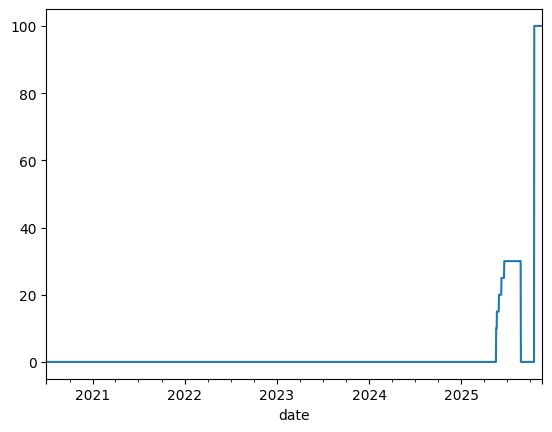

In [31]:
positions_df["PLTY"].plot()